# Quadrupole-octopole alignment, $S_\mathrm{QO}$

ToDo:
- How to compute alms of masked map?
- Plot maps just to double-check

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import polymv
import pylab as pl
import math
import sys
sys.path.insert(1, '../../scripts')
import CMBanom
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
# Parameters
lmax = 3
Nsims = 1000 #00
Nside_in = 128
load_stats_from_cluster = False

In [3]:
# Directories
sims_dir  = "../../data/sims/sims_1k/"
stats_dir = "../../data/stats/"
real_dir  = "../../data/real/"
masks_dir = "../../data/masks/"

# Planck maps
names_Planck  = [  "commander_nside_128",   "nilc_nside_128",   "sevem_nside_128",   "smica_nside_128",     "cleaned_70GHz_v3",     "cleaned_94GHz_v3",     "cleaned_100GHz_v3",     "cleaned_143GHz_v3"]
#names_Planck  = [  "commander_nside_128",   "nilc_nside_128",   "sevem_nside_128",   "smica_nside_128",     "cleaned_70GHz_v1",     "cleaned_94GHz_v1",     "cleaned_100GHz_v1",     "cleaned_143GHz_v1"]
#names_Planck  = [ "cleaned_70GHz_v1",     "cleaned_94GHz_v1",     "cleaned_100GHz_v1",     "cleaned_143GHz_v1",     "cleaned_70GHz_v3",     "cleaned_94GHz_v3",     "cleaned_100GHz_v3",     "cleaned_143GHz_v3"]
labels_Planck = [r"$\mathrm{Commander}$", r"$\mathrm{NILC}$", r"$\mathrm{SEVEM}$", r"$\mathrm{SMICA}$", r"$70\, \mathrm{GHz}$", r"$94\, \mathrm{GHz}$", r"$100\, \mathrm{GHz}$", r"$143\, \mathrm{GHz}$"]
colors        = ["tab:red", "teal",  "navy",  "gold", "tab:red",    "teal",   "navy",   "gold"]
lss           = [     "--",   "--",    "--",    "--",       "-",       "-",      "-",      "-"]
Nmaps = len(names_Planck)
index_Planck  = 0
index_Hayley  = 6

# Masks
names_mask  = [              "fullsky",                "stdmask",                  "commask"]
labels_mask = [r"$\mathrm{Full\ sky}$", r"$\mathrm{Std.\ mask}$", r"$\mathrm{Common\ mask}$"]
colors_mask = [                 "navy",              "firebrick",                 "tab:blue"]
mask_files = ["stdv_mask_1percent_v4.fits", "common-Mask-Int_cutoff0.9_Nside128.fits"]
Nmasks = len(names_mask)

# Multipoles l = 2,3,4,5
markers       = [".", ".", "s", "d", "x", "."]

In [4]:
# Font
plt.rc('font',**{'family':'Helvetica','size':16})
plt.rc('text', usetex=True)
font = {'family':'Helvetica',
        'color' : 'black',
        'size'  :  16}

In [5]:
# Load masks
masks = CMBanom.read_masks(masks_dir, mask_files, Nside_in)

In [6]:
# Read in maps in muK
maps_Planck = [hp.read_map(real_dir+f"map_{names_Planck[n]}.fits") for n in range(Nmaps)]

In [7]:
# Compute alms
alms_Planck = [[hp.sphtfunc.map2alm(maps_Planck[n]*masks[m], lmax=lmax) for n in range(Nmaps)] for m in range(Nmasks)]

In [8]:
# Compute multipole vectors Planck
mvs_Planck = [[],[],[]]
for m in range(Nmasks):
    for n in range(Nmaps):
        mvs_all_Planck = [polymv.mvs.m_vectors(alms_Planck[m][n], ell) for ell in range(lmax+1)]
        mvs_Planck[m].append([polymv.otherfuncs.mvs_north(mvs_all_Planck[ell]) for ell in range(lmax+1)])

In [9]:
# Print multipole vectors of \ell=2 and 3 to compare to Schwarz++ 2004

for m in range(Nmasks): 
    print("--------------")
    print(names_mask[m])
    for n in range(Nmaps):
        print("-- "+names_Planck[n]+" --")
        mvs_vec = [hp.ang2vec(theta=mvs_Planck[m][n][ell].T[0], phi=mvs_Planck[m][n][ell].T[1]) for ell in range(lmax+1)]
        mvs_lonlat= [hp.vec2ang(mvs_vec[ell], lonlat=True) for ell in range(lmax+1)]
        ell=2
        print("ell=2")
        for i in range(ell):
            print("v"+str(i)+" = (%(lon).2f, %(lat).2f)"%{"lon":mvs_lonlat[ell][0][i],"lat":mvs_lonlat[ell][1][i]})
        ell=3
        print("ell=3")
        for i in range(ell):
            print("v"+str(i)+" = (%(lon).2f, %(lat).2f)"%{"lon":mvs_lonlat[ell][0][i],"lat":mvs_lonlat[ell][1][i]})
        print(" ")

--------------
fullsky
-- commander_nside_128 --
ell=2
v0 = (3.03, 27.92)
v1 = (122.80, 23.25)
ell=3
v0 = (315.11, 6.62)
v1 = (24.49, 7.84)
v2 = (85.23, 37.73)
 
-- nilc_nside_128 --
ell=2
v0 = (15.76, 23.55)
v1 = (115.24, 19.78)
ell=3
v0 = (315.59, 7.78)
v1 = (23.28, 9.27)
v2 = (86.68, 37.12)
 
-- sevem_nside_128 --
ell=2
v0 = (14.76, 25.89)
v1 = (91.49, 12.13)
ell=3
v0 = (319.56, 0.81)
v1 = (31.53, 6.65)
v2 = (66.41, 35.84)
 
-- smica_nside_128 --
ell=2
v0 = (10.04, 24.91)
v1 = (119.26, 20.38)
ell=3
v0 = (315.55, 8.21)
v1 = (22.92, 9.22)
v2 = (87.47, 37.59)
 
-- cleaned_70GHz_v3 --
ell=2
v0 = (348.02, 17.68)
v1 = (118.14, 19.53)
ell=3
v0 = (317.53, 5.54)
v1 = (26.52, 8.24)
v2 = (83.33, 38.45)
 
-- cleaned_94GHz_v3 --
ell=2
v0 = (0.64, 9.66)
v1 = (108.39, 16.36)
ell=3
v0 = (317.73, 4.69)
v1 = (27.66, 8.33)
v2 = (82.41, 38.74)
 
-- cleaned_100GHz_v3 --
ell=2
v0 = (354.20, 14.77)
v1 = (114.11, 17.86)
ell=3
v0 = (316.61, 6.14)
v1 = (25.62, 8.75)
v2 = (83.66, 38.10)
 
-- cleaned_143GHz_v3

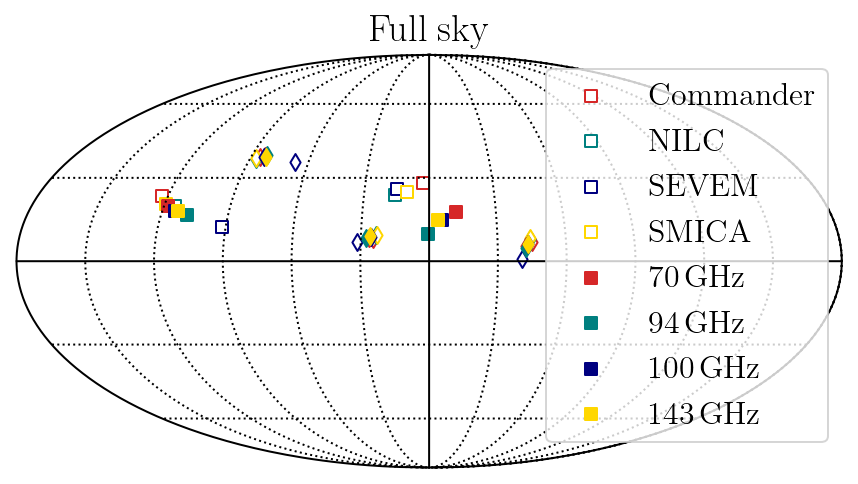

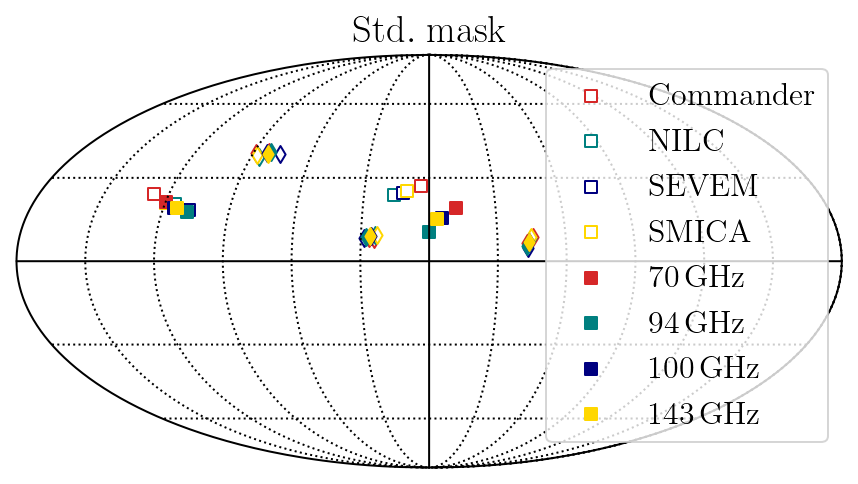

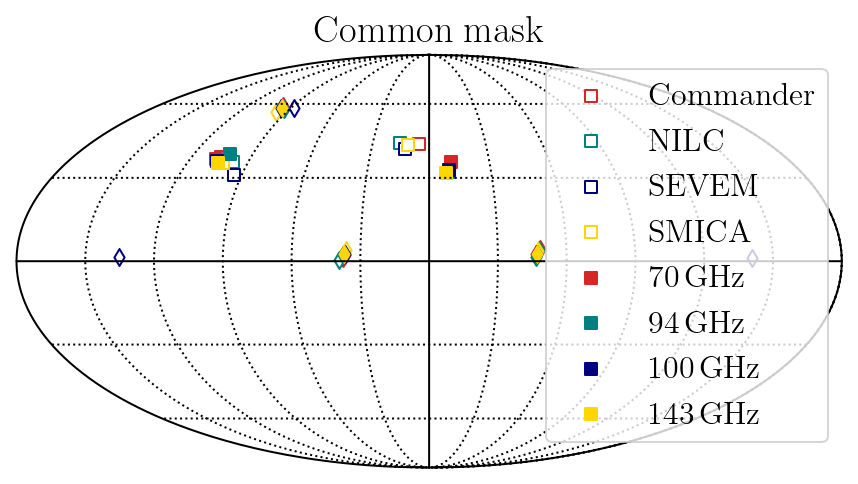

In [10]:
# Plot MVs on northern hemisphere
for m in range(Nmasks):
    hp.graticule()
    for n in range(Nmaps):
        for l in [2,3]:
            thetas = mvs_Planck[m][n][l].T[0]
            phis = mvs_Planck[m][n][l].T[1]
            if (l==2): label = labels_Planck[n];
            else: label=None
            if n>3: hp.projscatter(thetas, phis, marker=markers[l], color=colors[n], label=label)
            else: hp.projscatter(thetas, phis, marker=markers[l], color="white", edgecolor=colors[n], label=label)
    plt.legend(loc='upper right')
    plt.title(labels_mask[m])
    plt.show()

In [11]:
# Compute oriented-area vectors Planck
ws_Planck = [[],[],[]]
for m in range(Nmasks):
    for n in range(Nmaps):
        ws_n = [0,0]
        for l in range(2,lmax+1):
            ws_l = []
            for i in range(len(mvs_Planck[m][n][l])-1):
                mv1 = polymv.otherfuncs.to_cart(mvs_Planck[m][n][l])[i]
                for j in range(i+1, len(mvs_Planck[m][n][l])):
                    mv2 = polymv.otherfuncs.to_cart(mvs_Planck[m][n][l])[j]
                    ws_l.append(np.cross(mv1, mv2))
            ws_n.append(ws_l)
        ws_Planck[m].append(ws_n)

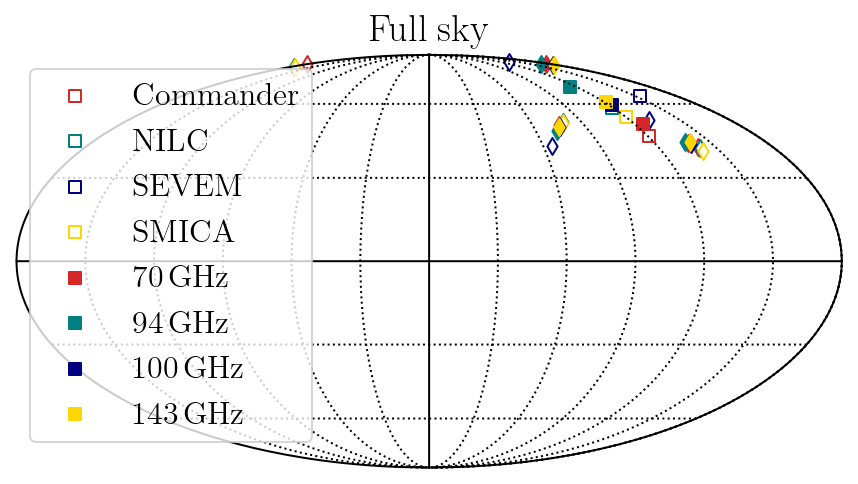

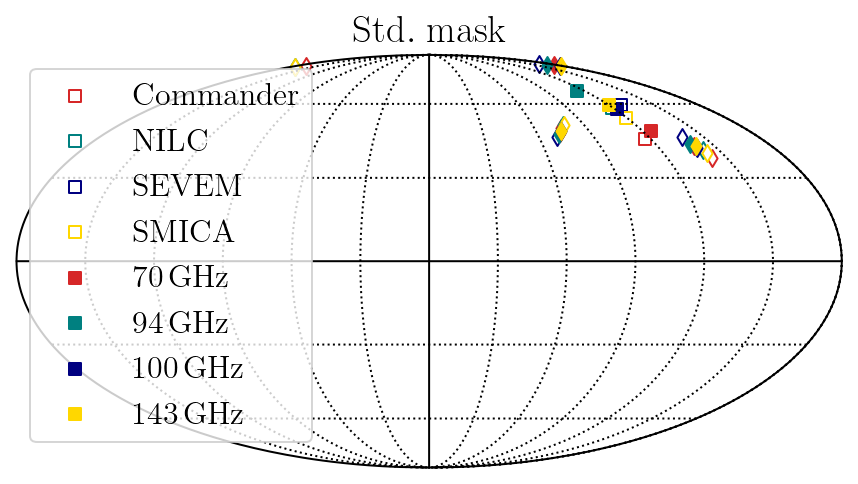

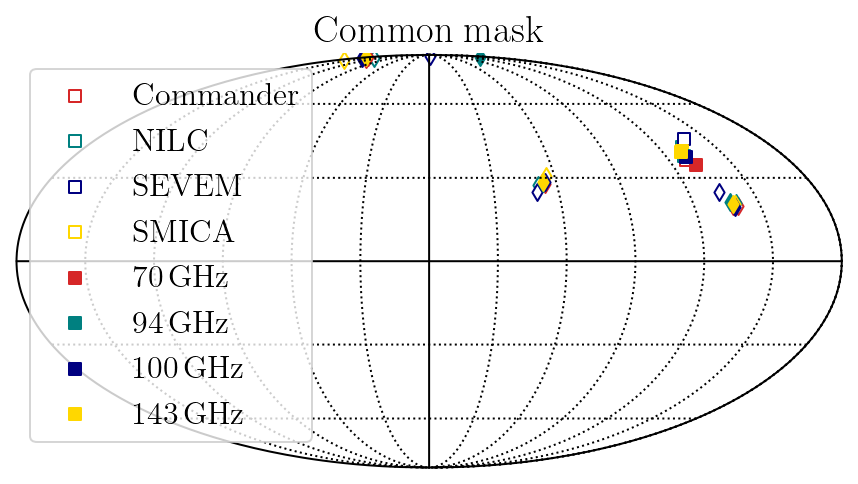

In [12]:
# Plot oriented areas from northern-sky MVs
for m in range(Nmasks):
    hp.graticule()
    for n in range(Nmaps): 
        for l in range(2, 4):
            thetas = np.zeros((len(ws_Planck[m][n][l])))
            phis = np.zeros((len(ws_Planck[m][n][l])))
            for i in range(len(ws_Planck[m][n][l])):
                thetas[i] = hp.vec2ang(ws_Planck[m][n][l][i])[0]
                phis[i] =  hp.vec2ang(ws_Planck[m][n][l][i])[1]
                if thetas[i] > np.pi/2:
                    thetas[i] = np.pi - thetas[i]
                    phis[i] = np.pi + phis[i]
            if (l==2): label = labels_Planck[n];
            else: label=None
            if n>3: hp.projscatter(thetas, phis, marker=markers[l], color=colors[n], label=label)
            else: hp.projscatter(thetas, phis, marker=markers[l], color="white", edgecolor=colors[n], label=label)
    plt.legend()
    plt.title(labels_mask[m])
    plt.show()

In [13]:
# Compute S_QO
SQO_Planck = np.array([[CMBanom.S_QO(ws_Planck[m][n]) for n in range(Nmaps)] for m in range(Nmasks)])

## Load or compute statistics of sims

In [14]:
if load_stats_from_cluster:
    SQO_sims = np.array([np.loadtxt(stats_dir+f"SQO_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)])
else:
    print("Load maps...")
    maps_sims = [hp.read_map(sims_dir+"map__"+str(n)+".fits")*1e3 for n in range(Nsims)]
    
    print("Compute multipole vectors...")
    mvs_sims = [CMBanom.compute_MVs(maps_sims, masks[m], lmax) for m in range(Nmasks)]
    
    print("Compute oriented-area vectors...")
    ws_sims = [CMBanom.compute_Ws(mvs_sims[m], lmax) for m in range(Nmasks)]

    print("Compute SQO...")
    SQO_sims = np.array([[CMBanom.S_QO(ws_sims[m][n]) for n in range(Nsims)] for m in range(Nmasks)])

Load maps...
Compute multipole vectors...
Compute oriented-area vectors...
Compute SQO...


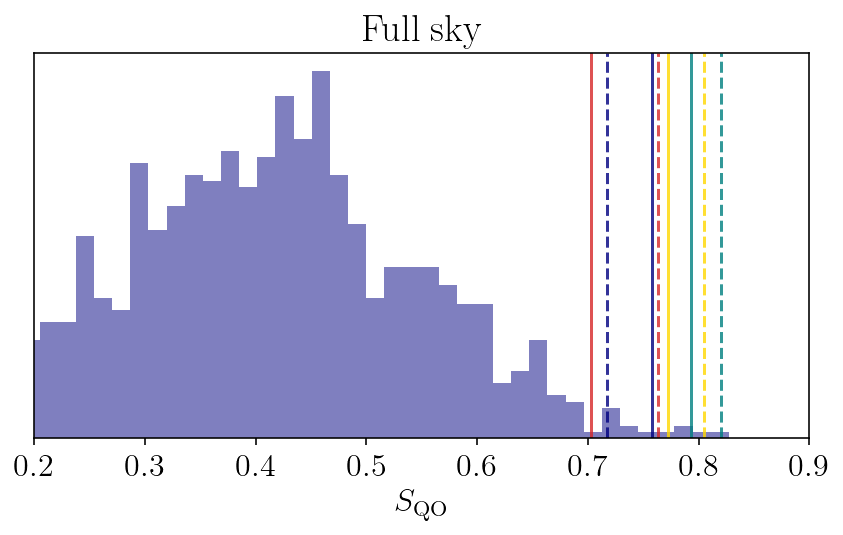

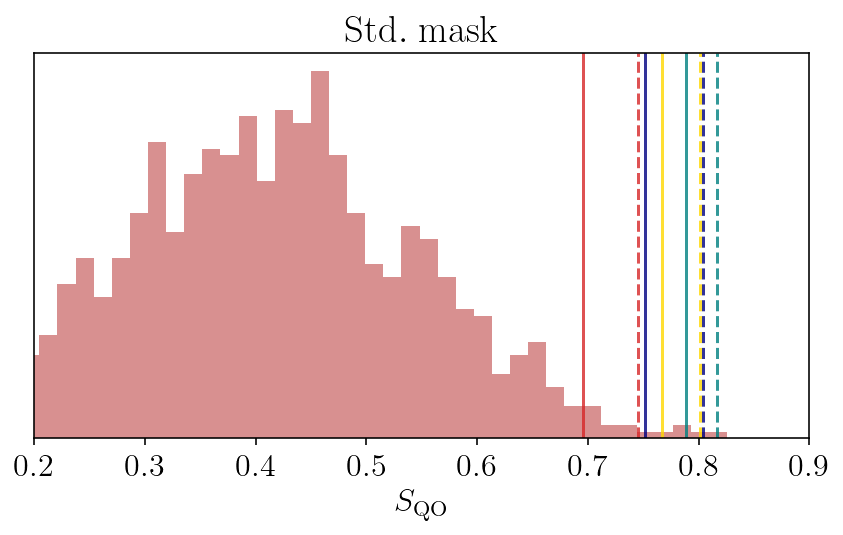

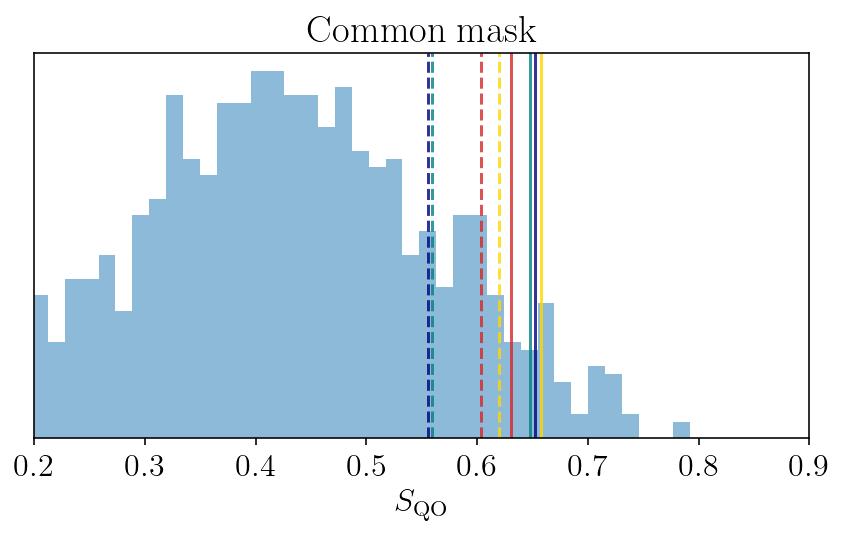

In [15]:
for m in range(Nmasks):
    bins = 10**np.linspace(2, 7, 100)
    h=plt.hist(SQO_sims[m], bins=50, color=colors_mask[m], alpha=0.5)
    for n in range(Nmaps):
        plt.axvline(SQO_Planck[m][n], color=colors[n], ls=lss[n], label=labels_Planck[n], alpha=0.8)
    plt.title(labels_mask[m])
    plt.xlim(0.2, 0.9)
    #plt.xscale("log")
    plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
    plt.xlabel(r"$S_\mathrm{QO}$")
    #plt.legend(loc="lower left")
    plt.tight_layout()
    plt.savefig("hist_S_QO_"+names_mask[m]+".pdf")
    plt.show()

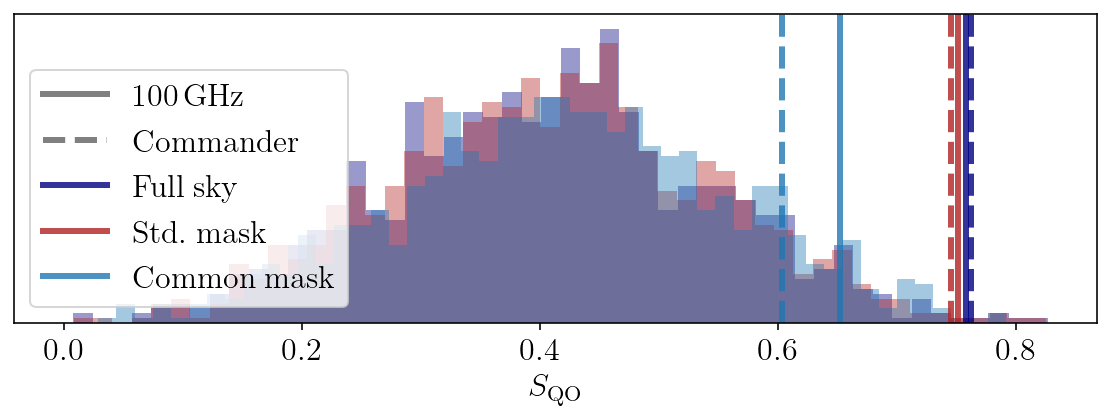

In [16]:
fig = plt.figure(figsize=(8, 3.2))
bins = 10**np.linspace(2, 7, 60)
plt.plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
plt.plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    h=plt.hist(SQO_sims[m], bins=50, color=colors_mask[m], alpha=0.4)
    plt.axvline(SQO_Planck[m][index_Hayley], color=colors_mask[m], lw=3, alpha=0.8, ls="-", label=labels_mask[m])
    plt.axvline(SQO_Planck[m][index_Planck], color=colors_mask[m], lw=3, alpha=0.8, ls="--")
#plt.xlim(7e2, 2e5)
#plt.xscale("log")
plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
plt.xlabel(r"$S_\mathrm{QO}$")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("hist_S_QO.pdf", format="PDF")
plt.show()

In [17]:
pvals = [[CMBanom.pval_higher(SQO_Planck[m][n], SQO_sims[m]) for n in range(Nmaps)] for m in range(Nmasks)]

In [18]:
for m in range(Nmasks):
    print("-------------")
    print(names_mask[m])
    for n in range(Nmaps):
        print(f"S_QO = {SQO_Planck[m][n]:.2f}, p-value: {100*pvals[m][n]:.2f}% ({names_Planck[n]})")

-------------
fullsky
S_QO = 0.76, p-value: 0.50% (commander_nside_128)
S_QO = 0.82, p-value: 0.10% (nilc_nside_128)
S_QO = 0.72, p-value: 1.00% (sevem_nside_128)
S_QO = 0.80, p-value: 0.10% (smica_nside_128)
S_QO = 0.70, p-value: 1.40% (cleaned_70GHz_v3)
S_QO = 0.79, p-value: 0.20% (cleaned_94GHz_v3)
S_QO = 0.76, p-value: 0.50% (cleaned_100GHz_v3)
S_QO = 0.77, p-value: 0.50% (cleaned_143GHz_v3)
-------------
stdmask
S_QO = 0.75, p-value: 0.60% (commander_nside_128)
S_QO = 0.82, p-value: 0.10% (nilc_nside_128)
S_QO = 0.80, p-value: 0.10% (sevem_nside_128)
S_QO = 0.80, p-value: 0.10% (smica_nside_128)
S_QO = 0.70, p-value: 1.50% (cleaned_70GHz_v3)
S_QO = 0.79, p-value: 0.20% (cleaned_94GHz_v3)
S_QO = 0.75, p-value: 0.50% (cleaned_100GHz_v3)
S_QO = 0.77, p-value: 0.50% (cleaned_143GHz_v3)
-------------
commask
S_QO = 0.60, p-value: 9.80% (commander_nside_128)
S_QO = 0.56, p-value: 16.90% (nilc_nside_128)
S_QO = 0.56, p-value: 17.60% (sevem_nside_128)
S_QO = 0.62, p-value: 7.60% (smica_ns

In [19]:
print("p-values")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{100*pvals[m][n]:.2f} ", end="")
    print("\\\\")

p-values
fullsky : &0.50 &0.10 &1.00 &0.10 &1.40 &0.20 &0.50 &0.50 \\
stdmask : &0.60 &0.10 &0.10 &0.10 &1.50 &0.20 &0.50 &0.50 \\
commask : &9.80 &16.90 &17.60 &7.60 &6.60 &5.20 &5.00 &4.10 \\


In [20]:
print("stats")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{SQO_Planck[m][n]:.2f} ", end="")
    print("\\\\")

stats
fullsky : &0.76 &0.82 &0.72 &0.80 &0.70 &0.79 &0.76 &0.77 \\
stdmask : &0.75 &0.82 &0.80 &0.80 &0.70 &0.79 &0.75 &0.77 \\
commask : &0.60 &0.56 &0.56 &0.62 &0.63 &0.65 &0.65 &0.66 \\


## Is the common mask also producing MVs of sims pointing in the plane?
No, not for first 50 sims.

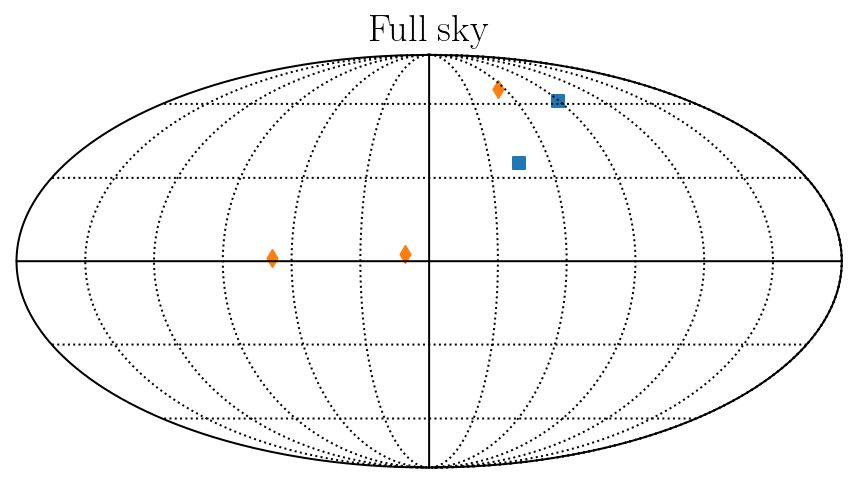

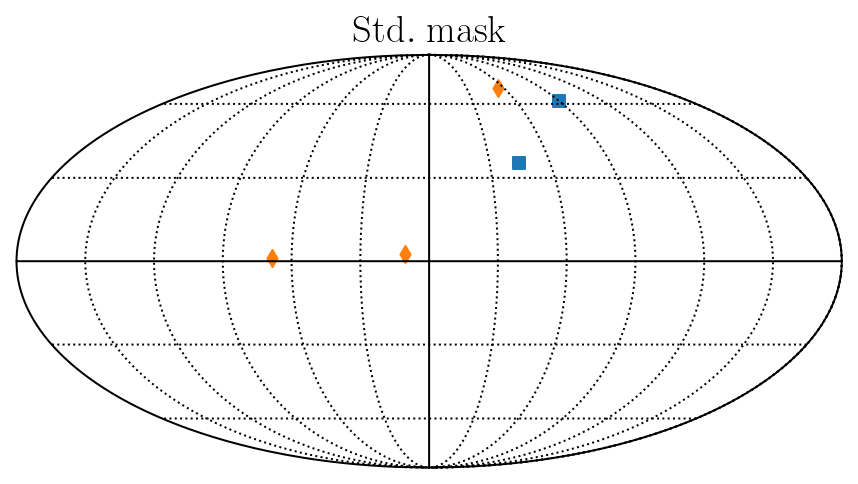

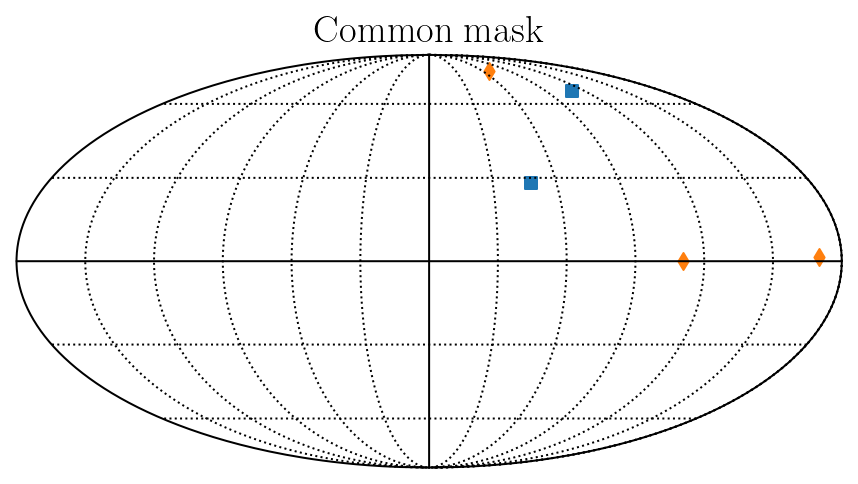

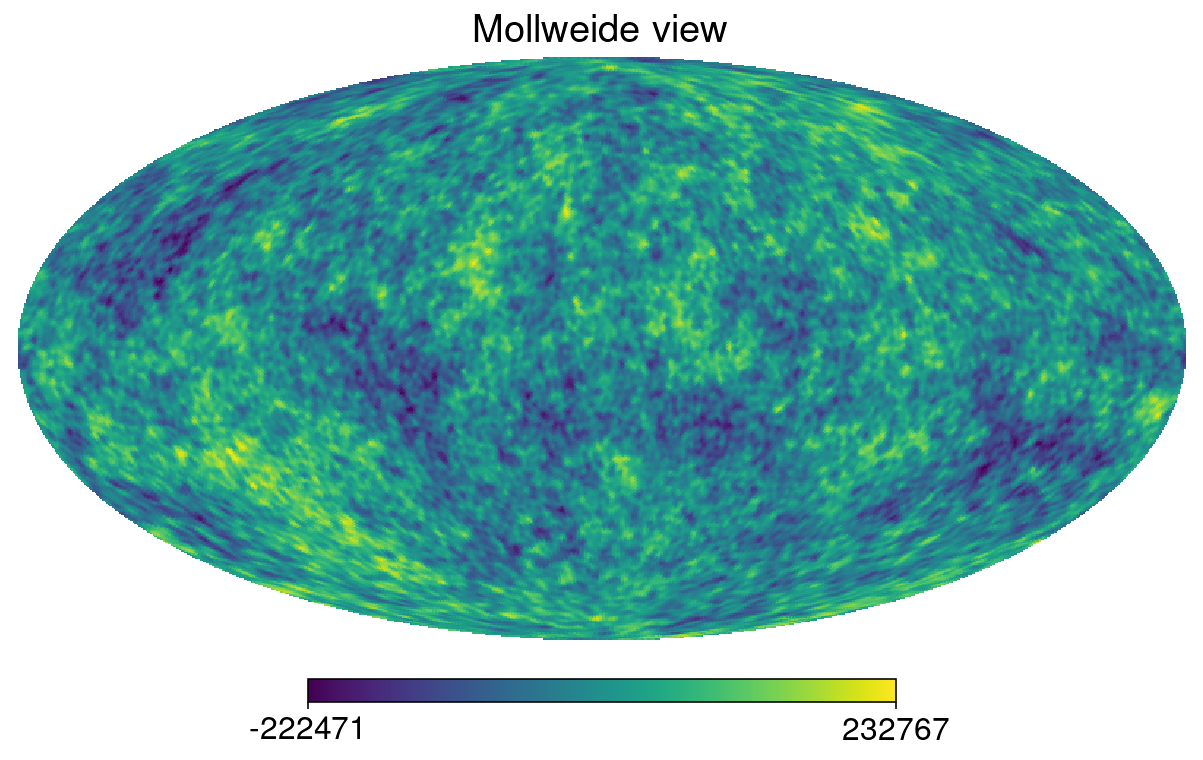

In [21]:
# Plot MVs on northern hemisphere
# 20: has quadrupole in the galactic plane
# 46: has 2 octopole MVs in plane for all mask choices
if load_stats_from_cluster==False:
    for m in range(Nmasks):
        hp.graticule()
        for n in range(46, 47):
            for l in [2,3]:
                thetas = mvs_sims[m][n][l].T[0]
                phis = mvs_sims[m][n][l].T[1]
                hp.projscatter(thetas, phis, marker=markers[l])
        plt.title(labels_mask[m])
        plt.show()
    hp.mollview(maps_sims[46])

In [22]:
# # Plot MVs on northern hemisphere
# n = 2
# for m in range(Nmasks):
#     hp.graticule()
#     for l in [2,3]:
#         thetas = mvs_Planck[m][n][l].T[0]
#         phis = mvs_Planck[m][n][l].T[1]
#         if (l==2): label = labels_Planck[n];
#         else: label=None
#         if n>3: hp.projscatter(thetas, phis, marker=markers[l], color=colors[n], label=label)
#         else: hp.projscatter(thetas, phis, marker=markers[l], color="white", edgecolor=colors[n], label=label)
#     plt.legend(loc='upper right')
#     plt.title(labels_mask[m])
#     plt.show()
# hp.mollview(maps_Planck[n])